In [1]:
import copy
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
seed = 1234
np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Parameters

In [4]:
MODEL_SAVE_PATH = "models/nn.pt"
BS = 64
LR = 1e-3
EPOCH = 6

## Data Loading

In [5]:
DATA = pd.read_csv("data/proc_training_nn.csv")
TEST_DATA = pd.read_csv("data/proc_testing_nn.csv")

## Preprocessing
### Normalization

In [6]:
def normalize(col):
    min = col.min()
    max = col.max()
    return (col - min)/(max - min)
    
unnorm_feats = ["locdt", "loctm", "conam", "iterm", "fc_ratio", "mcc_fr", "region_fr", "chid_fr"]
for feat in unnorm_feats:
    DATA[feat] = normalize(DATA[feat])
    TEST_DATA[feat] = normalize(TEST_DATA[feat])

In [7]:
X = DATA.drop(columns="label")
y = DATA["label"]

In [8]:
TEST_txkey = TEST_DATA["txkey"]
X_test = TEST_DATA.drop(columns="txkey")

### Train Test Split

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3)

### Oversampling / Undersampling

In [10]:
pos_num = (y_train == 1).sum()

X_train_pos = X_train[y_train == 1]
X_train_neg = X_train[y_train == 0].sample(n=pos_num * 10)

y_train_pos = y_train[y_train == 1]
y_train_neg = y_train[X_train_neg.index]

X_train = pd.concat((X_train_pos, X_train_neg))
y_train = pd.concat((y_train_pos, y_train_neg))

X_train, y_train = BorderlineSMOTE().fit_resample(X_train, y_train)

## Data Loader Construction

In [11]:
class CustomDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X.to_numpy().astype(np.float32))
        if y is None:
            self.y = None
        else:
            self.y = torch.tensor(y.to_numpy().astype(np.float32))
        self.len = X.shape[0]

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

    def __len__(self):
        return self.len

In [12]:
train_loader = DataLoader(
    CustomDataset(X_train, y_train),
    batch_size=BS,
    shuffle=True,
)

valid_loader = DataLoader(
    CustomDataset(X_valid, y_valid),
    batch_size=BS,
    shuffle=False,
)

test_loader = DataLoader(
    CustomDataset(X_test),
    batch_size=BS,
    shuffle=False,
)

## Model Construction

In [13]:
class Model(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.fc1 = nn.Linear(input_shape, 1024)
        self.fc2 = nn.Linear(1024, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.sigmoid(self.fc3(x))
        return x

## Training & Validation

In [14]:
def draw_chart(title, epochs, train_log, valid_log):
    plt.plot(epochs, train_log, label='Training')
    plt.plot(epochs, valid_log, label='Validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

In [15]:
def f1_score(y_pred, y_true):
    TP = ((y_pred == 1) & (y_true == 1)).sum()
    pre = TP / ((y_pred == 1).sum() + 1e-8)
    rec = TP / ((y_true == 1).sum() + 1e-8)
    return ((2 * pre * rec)/(pre + rec + 1e-8)).cpu()

In [16]:
def train_and_valid(model, data_loaders, criterion, optimizer, epoch_num):
    loss_log = { 'train': [], 'valid': [] }
    f1_log = { 'train': [], 'valid': [] }
    best_weights = None
    best_f1 = 0
    
    for epoch in range(epoch_num):
        print(f'Epoch: {epoch + 1}/{epoch_num}')

        for phase in ['train', 'valid']:
            running_loss = 0
            running_f1 = 0
            
            if phase == 'train':
                model.train()
            else:
                model.eval()
                
            for inputs, labels in data_loaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs).squeeze()
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                preds = outputs.round()

                running_loss += loss.item()
                running_f1 += f1_score(preds, labels)

            batch_num = len(data_loaders[phase])
            epoch_loss = running_loss / batch_num
            epoch_f1 = running_f1 / batch_num

            loss_log[phase].append(epoch_loss)
            f1_log[phase].append(epoch_f1)
            
            print(f'[{phase}] Loss: {epoch_loss}, F1 Score: {epoch_f1}')

            if phase == 'valid' and epoch_f1 > best_f1:
                best_weights = copy.deepcopy(model.state_dict())
                best_f1 = epoch_f1

    epochs = np.arange(1, epoch_num + 1)
    draw_chart('Loss', epochs, loss_log['train'], loss_log['valid'])
    draw_chart('F1 Score', epochs, f1_log['train'], f1_log['valid'])

    return best_weights

Epoch: 1/6
[train] Loss: 0.06592024853729517, F1 Score: 0.9878550171852112
[valid] Loss: 0.05098180959542477, F1 Score: 0.19137242436408997
Epoch: 2/6
[train] Loss: 0.016706942846381797, F1 Score: 0.9964658617973328
[valid] Loss: 0.01432479630783501, F1 Score: 0.1975822001695633
Epoch: 3/6
[train] Loss: 0.01041923322541532, F1 Score: 0.997497022151947
[valid] Loss: 0.012126678486291176, F1 Score: 0.20005792379379272
Epoch: 4/6
[train] Loss: 0.008631978440433919, F1 Score: 0.9978264570236206
[valid] Loss: 0.009145087505911998, F1 Score: 0.1999547779560089
Epoch: 5/6
[train] Loss: 0.007854924526902734, F1 Score: 0.9980261921882629
[valid] Loss: 0.009282810293669213, F1 Score: 0.20100557804107666
Epoch: 6/6
[train] Loss: 0.007288138188811404, F1 Score: 0.9981716275215149
[valid] Loss: 0.0075952973012475495, F1 Score: 0.2008763998746872


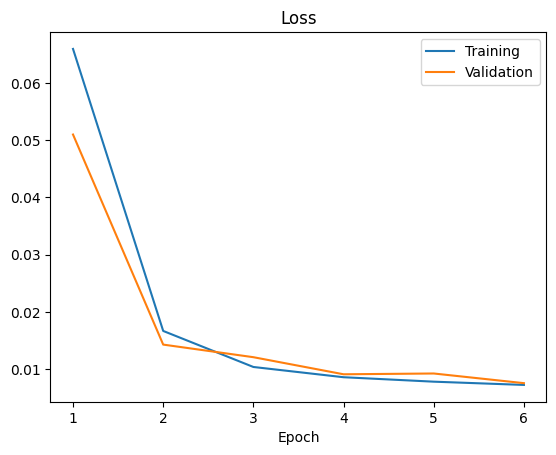

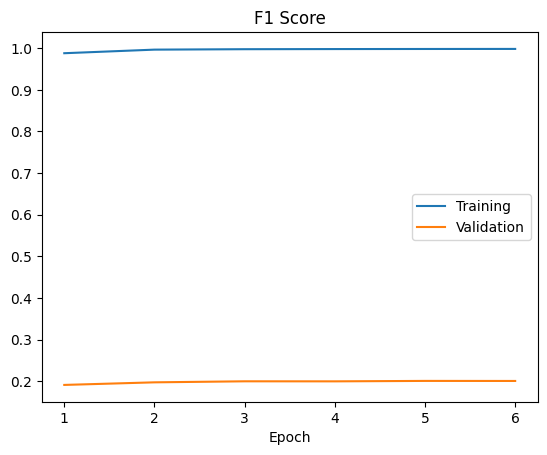

<All keys matched successfully>

In [17]:
model = Model(len(X_train.columns)).to(device)
data_loaders = { 'train': train_loader, 'valid': valid_loader }
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

best_weights = train_and_valid(model, data_loaders, criterion, optimizer, EPOCH)
torch.save(best_weights, MODEL_SAVE_PATH)
model.load_state_dict(best_weights)

## Predict

In [31]:
model.eval()

preds = torch.tensor([])

for inputs in test_loader:
    inputs = inputs.to(device)
    outputs = model(inputs).squeeze()
    preds = torch.cat((preds, outputs.round().cpu()))

preds = preds.int()

In [32]:
res = {
    'txkey': TEST_txkey,
    'label': preds,
}

pd.DataFrame(res).to_csv('preds.csv', index=False)

In [33]:
pd.Series(preds).value_counts()

0    598414
1      1768
Name: count, dtype: int64